# Libraries

In [15]:
import numpy as np
from scipy.optimize import curve_fit
%matplotlib inline
import matplotlib.pyplot as plt

# Fitting Algorithm

In [16]:
# define 4PL and 5PL
def fourPL(x, A, B, C, D):
    return ((A-D)/(1.0+((x/C)**(B)))) + D

#Reparameterised from Liao et Liu 2009 J Chemometrics
def fivePL(x, A, B, C, D, E):
    return ((A-D)/((1+(2**(1/E)-1)*(x/C)**(B))**(E))) + D

# Plates Data

## Dilution Factors

In [17]:
# Direct ELISA used 1:3 serial dilution
Sandwich_x = np.array([1.7e+10, 1.7e+10, 5.6666e+9, 5.6666e+9, 1.8887e+9, 1.8887e+9, 6.2956e+8, 6.2956e+8, 2.0985e+8, 2.0985e+8, 6.9951e+7, 6.9951e+7, 2.3317e+7, 2.3317e+7])
Sandwich_x_norm = np.array([100, 100, 33.33, 33.33, 11.11, 11.11, 3.703, 3.703, 1.234, 1.234, 0.4115, 0.4115, 0.1372, 0.1372])
# Direct ELISA used 1:5 serial dilution
Direct_x = np.array([1.7e+10, 1.7e+10, 3.4e+9, 3.4e+9, 6.8e+8, 6.8e+8, 1.36e+8, 1.36e+8, 2.72e+7, 2.72e+7, 5.44e+6, 5.44e+6, 1.088e+6, 1.088e+6])
Direct_x_norm = np.array([1000, 1000, 200, 200, 40, 40, 8, 8, 1.6, 1.6, 0.32, 0.32, 0.064, 0.064])

## Plate 1: pH 7.4 Testing (A11, H06, G07)

In [18]:
Sandwich_a11_ph74 = np.array([2.723, 2.17, 1.8522, 1.0073, 1.3102, 1.4684, 0.6433, 0.6012, 0.2708, 0.2604, 0.124, 0.1508, 0.0749, 0.0857])
Sandwich_h06_ph74 = np.array([0.1232, 0.06, 0.0529, 0.053, 0.0513, 0.0522, 0.0509, 0.0517, 0.0527, 0.0622, 0.0523,0.0537, 0.0527, 0.0518])
Sandwich_g07_ph74 = np.array([0.1253, 0.1298, 0.0891, 0.0655, 0.0621, 0.0676, 0.0544, 0.0593, 0.0537, 0.0538, 0.0546, 0.0535, 0.0515, 0.0553])
Direct_a11_ph74 = np.array([2.4977, 2.9004, 2.4026, 2.6643, 1.9843, 1.7593, 0.9499, 0.8392, 0.4851, 0.8588, 0.217, 0.2657, 0.097, 0.0963])
Direct_h06_ph74 = np.array([3.1942, 2.7667, 2.6627, 2.5054, 1.8777, 1.5261, 0.869, 0.7225, 1.1462, 0.786, 0.3967, 0.2875, 0.1329, 0.1197])
Direct_g07_ph74 = np.array([3.0443, 2.454, 3.1031, 2.8425, 2.7536, 2.7425, 1.8775, 1.7662, 0.9391, 0.8156, 1.2848, 1.293, 0.4152, 0.5129])

## Plate 2: pH 7.4 Testing (G08, B03, B04)

In [19]:
Sandwich_g08_ph74 = np.array([0.0587,0.0583,0.0543,0.0543,0.0515,0.0557,0.051,0.0587,0.0542,0.0547,0.0519,0.089,0.0523,0.1223])
Sandwich_b03_ph74 = np.array([2.5342,2.3368,1.9175,1.5878,1.3286,0.8972,0.6123,0.3914,0.2439,0.1338,0.1149,0.0938,0.0736,0.0634])
Sandwich_b04_ph74 = np.array([0.0644,0.0566,0.0641,0.0528,0.0549,0.0522,0.0541,0.0565,0.054,0.0513,0.0591,0.0511,0.0518,0.0505])
Direct_g08_ph74 = np.array([2.6606,2.6981,2.1256,2.0731,1.441,1.1032,1.148,1.2811,0.798,0.5684,0.2417,0.2068,0.0889,0.0861])
Direct_b03_ph74 = np.array([2.4698,2.3861,1.773,1.7564,0.9036,0.8287,0.6368,0.5686,0.5806,0.7936,0.2319,0.2751,0.1028,0.0811])
Direct_b04_ph74 = np.array([2.5303,2.5536,1.6934,1.6497,0.7943,0.7162,1.1026,0.7946,0.4516,0.3123,0.147,0.2934,0.0753,0.0805])

## Plate 3: pH 5.8 Testing (H06, G07, G08)

In [20]:
Sandwich_h06_ph58 = np.array([0.0558,0.0543,0.05,0.049,0.0479,0.0471,0.0475,0.0484,0.0483,0.0486,0.048,0.047,0.0475,0.0484])
Sandwich_g07_ph58 = np.array([0.1019,0.0874,0.0616,0.0615,0.0538,0.0539,0.0509,0.0498,0.0502,0.0504,0.0502,0.0488,0.0509,0.049])
Sandwich_g08_ph58 = np.array([0.0593,0.0581,0.0522,0.0521,0.0516,0.0511,0.0593,0.0497,0.0491,0.0494,0.0506,0.0489,0.0486,0.0489])
Direct_h06_ph58 = np.array([2.6839,2.3339,2.1069,2.0385,1.4067,1.3109,0.7758,0.8021,0.508,0.7318,0.2365,0.1828,0.0752,0.074])
Direct_g07_ph58 = np.array([2.253,2.2174,2.5932,2.4143,2.4609,2.2175,1.6942,1.4828,0.9354,0.8541,0.9143,0.5923,0.3367,0.3232])
Direct_g08_ph58 = np.array([2.2229,2.4968,1.7312,1.837,1.0936,1.1985,0.9631,1.139,0.5905,0.6115,0.1853,0.173,0.0706,0.0791])

# Plot

## Untransformed X-axis

Plot of untransformed data


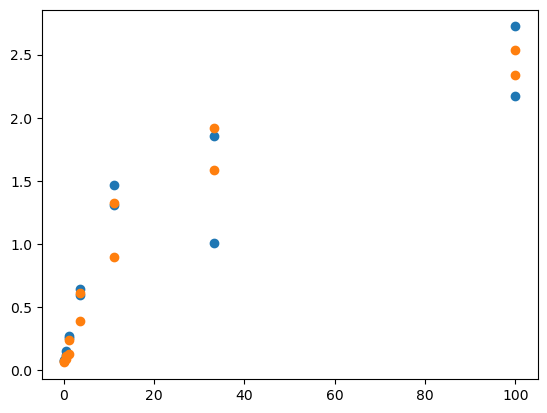

In [21]:
print('Plot of untransformed data')
x_min, x_max = np.amin(Sandwich_x_norm), np.amax(Sandwich_x_norm)
plt.scatter(Sandwich_x_norm, Sandwich_a11_ph74)
plt.scatter(Sandwich_x_norm, Sandwich_b03_ph74)
plt.show()

## 5 Parameter Logistic Model

5 Parameter Logistic Model
popt: [8.09270833e-34 8.74231928e-01 4.89486961e+13 2.86977628e+01
 2.58832558e-02]
RSME: 0.2462805604760247
R-squared: 0.9134564553398461


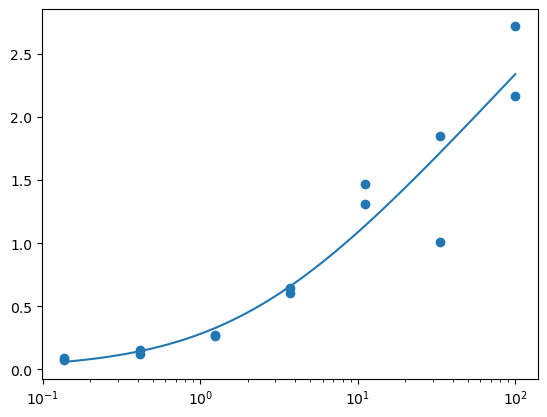

In [22]:
print('5 Parameter Logistic Model')

lower_bounds = (0, 0, 0, 0, 0)
upper_bounds = (np.inf, np.inf, np.inf, np.inf, np.inf)
popt, pcov = curve_fit(fivePL, Sandwich_x_norm, Sandwich_a11_ph74, bounds=(lower_bounds, upper_bounds), maxfev=100000)
print('popt:', popt)

# calculate the error (RSME and R^2)
prediction = fivePL(Sandwich_x_norm, *popt)
ABSE = prediction - Sandwich_a11_ph74
SE = np.square(ABSE)
MSE = np.mean(SE)
RMSE = np.sqrt(MSE)
Rsquared = 1.0 - (np.var(ABSE) / np.var(Sandwich_a11_ph74))
print('RSME:', RMSE)
print('R-squared:', Rsquared)

# plot the curve
x_min, x_max = np.amin(Sandwich_x_norm), np.amax(Sandwich_x_norm)
xs = np.linspace(x_min, x_max, 10000)
plt.xscale('log')
plt.scatter(Sandwich_x_norm, Sandwich_a11_ph74)
plt.plot(xs, fivePL(xs, *popt))
plt.show()

## Sandwich ELISA Plot

h06: [1.83352953e-02 8.67749786e+01 3.59684451e-02 4.91285763e-02
 6.00039263e+01]
g07: [ 0.050025   22.09895362 11.92533209  0.0781     25.73750935]
g08: [ 0.05319366 38.24081547  0.10514186  0.05206429 25.73668452]


/tmp/ipykernel_2672643/3744648640.py:7: RuntimeWarning: overflow encountered in power
  return ((A-D)/((1+(2**(1/E)-1)*(x/C)**(B))**(E))) + D


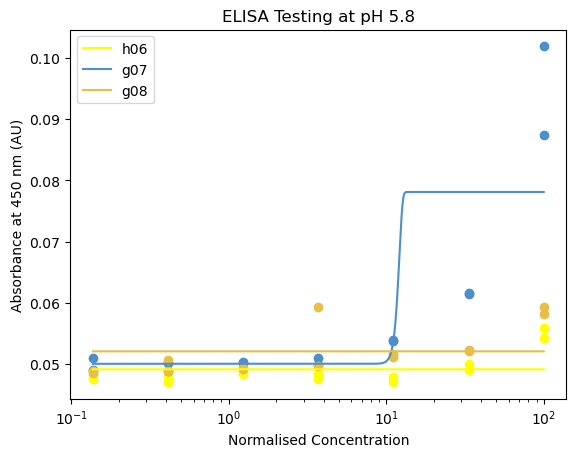

In [24]:
# pH 5.8
popth06, pcovh06 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_h06_ph58, bounds=(lower_bounds, upper_bounds), maxfev=100000)
poptg07, pcovg07 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_g07_ph58, bounds=(lower_bounds, upper_bounds), maxfev=100000)
poptg08, pcovg08 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_g08_ph58, bounds=(lower_bounds, upper_bounds), maxfev=100000)

print('h06:', popth06)
print('g07:', poptg07)
print('g08:', poptg08)

xs = np.linspace(x_min, x_max, 10000)
ch06 = "#FFFF00"
cg07 = "#4D8FCB"
cg08 = "#E7BF47"

fig, ax = plt.subplots()
ax.plot(xs, fivePL(xs, *popth06), color=ch06, label='h06')
ax.plot(xs, fivePL(xs, *poptg07), color=cg07, label='g07')
ax.plot(xs, fivePL(xs, *poptg08), color=cg08, label='g08')

ax.scatter(Sandwich_x_norm, Sandwich_h06_ph58, color=ch06)
ax.scatter(Sandwich_x_norm, Sandwich_g07_ph58, color=cg07)
ax.scatter(Sandwich_x_norm, Sandwich_g08_ph58, color=cg08)

ax.legend(['h06', 'g07', 'g08'])

plt.title('ELISA Testing at pH 5.8')
plt.xlabel('Normalised Concentration')
plt.ylabel('Absorbance at 450 nm (AU)')
plt.xscale('log')
plt.show()

/tmp/ipykernel_2672643/3744648640.py:7: RuntimeWarning: overflow encountered in power
  return ((A-D)/((1+(2**(1/E)-1)*(x/C)**(B))**(E))) + D


a11: [8.09270833e-34 8.74231928e-01 4.89486961e+13 2.86977628e+01
 2.58832558e-02]
h06: [5.29612953e-02 3.37435487e+00 1.23423170e+03 2.68170780e+02
 6.67236676e+02]
g07: [5.37217410e-02 9.85181185e-01 2.02469893e+03 2.14252049e+00
 2.10878713e+02]
g08: [0.08754956 4.20845275 0.40351901 0.05514    7.8691954 ]
b03: [7.56638727e-02 1.70937997e+00 1.01689907e+14 2.97598444e+01
 1.29169813e-02]
b04: [5.35496064e-02 7.60515384e+00 3.09279963e+01 6.05000005e-02
 8.87081709e+01]


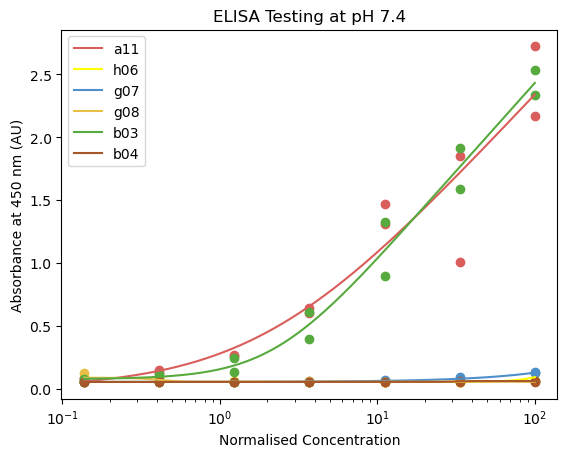

In [25]:
# pH 7.4
popta11, pcova11 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_a11_ph74, bounds=(0, np.inf), maxfev=100000)
popth06, pcovh06 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_h06_ph74, bounds=(0, np.inf), maxfev=100000)
poptg07, pcovg07 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_g07_ph74, bounds=(0, np.inf), maxfev=100000)
poptg08, pcovg08 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_g08_ph74, bounds=(0, np.inf), maxfev=100000)
poptb03, pcovb03 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_b03_ph74, bounds=(0, np.inf), maxfev=100000)
poptb04, pcovb04 = curve_fit(fivePL, Sandwich_x_norm, Sandwich_b04_ph74, bounds=(0, np.inf), maxfev=100000)

print('a11:', popta11)
print('h06:', popth06)
print('g07:', poptg07)
print('g08:', poptg08)
print('b03:', poptb03)
print('b04:', poptb04)

xs = np.linspace(x_min, x_max, 10000)
ca11 = "#D95E5B"  # Red
ch06 = "#FFFF00"  # Yellow
cg07 = "#4D8FCB"  # Blue
cg08 = "#E7BF47"  # Yellow
cb03 = "#57AA3E"  # Green
cb04 = "#A65628"  # Brown

fig, ax = plt.subplots()
ax.plot(xs, fivePL(xs, *popta11), color=ca11, label='a11')
ax.plot(xs, fivePL(xs, *popth06), color=ch06, label='h06')
ax.plot(xs, fivePL(xs, *poptg07), color=cg07, label='g07')
ax.plot(xs, fivePL(xs, *poptg08), color=cg08, label='g08')
ax.plot(xs, fivePL(xs, *poptb03), color=cb03, label='b03')
ax.plot(xs, fivePL(xs, *poptb04), color=cb04, label='b04')

ax.scatter(Sandwich_x_norm, Sandwich_a11_ph74, color=ca11)
ax.scatter(Sandwich_x_norm, Sandwich_h06_ph74, color=ch06)
ax.scatter(Sandwich_x_norm, Sandwich_g07_ph74, color=cg07)
ax.scatter(Sandwich_x_norm, Sandwich_g08_ph74, color=cg08)
ax.scatter(Sandwich_x_norm, Sandwich_b03_ph74, color=cb03)
ax.scatter(Sandwich_x_norm, Sandwich_b04_ph74, color=cb04)

ax.legend(['a11', 'h06', 'g07', 'g08', 'b03', 'b04'])

plt.title('ELISA Testing at pH 7.4')
plt.xlabel('Normalised Concentration')
plt.ylabel('Absorbance at 450 nm (AU)')
plt.xscale('log')
plt.show()

## Direct ELISA

h06: [2.97158996e-34 4.12056366e-01 3.53371889e+01 2.69158630e+00
 1.78747858e+03]
g07: [3.68690843e-01 6.69914218e-01 4.82843624e+00 2.38987918e+00
 6.37298468e+03]
g08: [1.20803466e-108 5.42516665e-001 4.65825513e+011 1.42469202e+001
 4.78588172e-002]


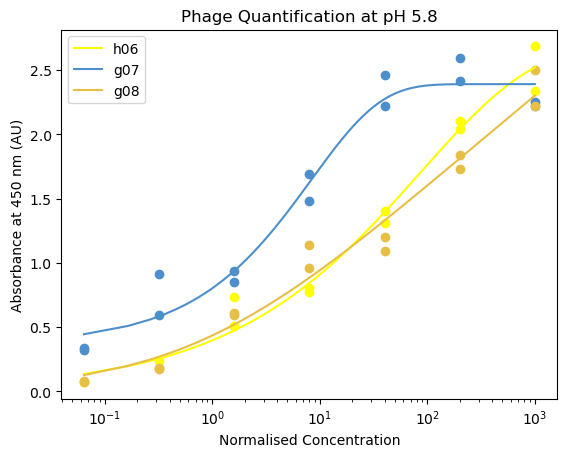

In [28]:
# pH 5.8
popth06, pcovh06 = curve_fit(fivePL, Direct_x_norm, Direct_h06_ph58, bounds=(lower_bounds, upper_bounds), maxfev=100000)
poptg07, pcovg07 = curve_fit(fivePL, Direct_x_norm, Direct_g07_ph58, bounds=(lower_bounds, upper_bounds), maxfev=100000)
poptg08, pcovg08 = curve_fit(fivePL, Direct_x_norm, Direct_g08_ph58, bounds=(lower_bounds, upper_bounds), maxfev=100000)

print('h06:', popth06)
print('g07:', poptg07)
print('g08:', poptg08)

x_min = np.amin(Direct_x_norm)
x_max = np.amax(Direct_x_norm)
xs = np.linspace(x_min, x_max, 10000)
ch06 = "#FFFF00"
cg07 = "#4D8FCB"
cg08 = "#E7BF47"

fig, ax = plt.subplots()
ax.plot(xs, fivePL(xs, *popth06), color=ch06, label='h06')
ax.plot(xs, fivePL(xs, *poptg07), color=cg07, label='g07')
ax.plot(xs, fivePL(xs, *poptg08), color=cg08, label='g08')

ax.scatter(Direct_x_norm, Direct_h06_ph58, color=ch06)
ax.scatter(Direct_x_norm, Direct_g07_ph58, color=cg07)
ax.scatter(Direct_x_norm, Direct_g08_ph58, color=cg08)

ax.legend(['h06', 'g07', 'g08'])

plt.title('Phage Quantification at pH 5.8')
plt.xlabel('Normalised Concentration')
plt.ylabel('Absorbance at 450 nm (AU)')
plt.xscale('log')
plt.show()

a11: [5.86967582e-02 5.48100960e-01 1.72503634e+01 2.71344467e+00
 4.44470941e+03]
h06: [1.21839547e-01 4.52374254e-01 3.28712306e+01 3.12907454e+00
 4.44983380e+03]
g07: [7.52132424e-01 9.04808419e-01 8.20855326e+00 2.86282530e+00
 1.39455762e+03]
g08: [2.82264151e-311 5.30807480e-001 4.17224406e+011 1.63378520e+001
 4.92164214e-002]
b03: [3.70710393e-02 3.14943084e-01 2.97739268e+03 6.25693051e+00
 3.46274460e+02]
b04: [8.91443025e-11 3.09117940e-01 1.35229200e+04 9.48829168e+00
 1.04380731e+03]


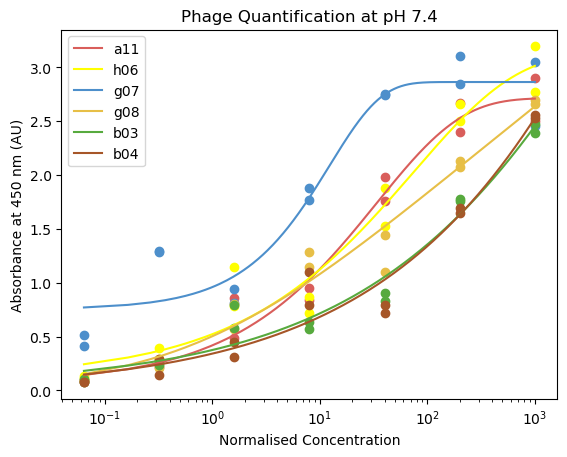

In [29]:
# pH 7.4
popta11, pcova11 = curve_fit(fivePL, Direct_x_norm, Direct_a11_ph74, bounds=(0, np.inf), maxfev=100000)
popth06, pcovh06 = curve_fit(fivePL, Direct_x_norm, Direct_h06_ph74, bounds=(0, np.inf), maxfev=100000)
poptg07, pcovg07 = curve_fit(fivePL, Direct_x_norm, Direct_g07_ph74, bounds=(0, np.inf), maxfev=100000)
poptg08, pcovg08 = curve_fit(fivePL, Direct_x_norm, Direct_g08_ph74, bounds=(0, np.inf), maxfev=100000)
poptb03, pcovb03 = curve_fit(fivePL, Direct_x_norm, Direct_b03_ph74, bounds=(0, np.inf), maxfev=100000)
poptb04, pcovb04 = curve_fit(fivePL, Direct_x_norm, Direct_b04_ph74, bounds=(0, np.inf), maxfev=100000)

print('a11:', popta11)
print('h06:', popth06)
print('g07:', poptg07)
print('g08:', poptg08)
print('b03:', poptb03)
print('b04:', poptb04)

xs = np.linspace(x_min, x_max, 10000)
ca11 = "#D95E5B"  # Red
ch06 = "#FFFF00"  # Yellow
cg07 = "#4D8FCB"  # Blue
cg08 = "#E7BF47"  # Yellow
cb03 = "#57AA3E"  # Green
cb04 = "#A65628"  # Brown

fig, ax = plt.subplots()
ax.plot(xs, fivePL(xs, *popta11), color=ca11, label='a11')
ax.plot(xs, fivePL(xs, *popth06), color=ch06, label='h06')
ax.plot(xs, fivePL(xs, *poptg07), color=cg07, label='g07')
ax.plot(xs, fivePL(xs, *poptg08), color=cg08, label='g08')
ax.plot(xs, fivePL(xs, *poptb03), color=cb03, label='b03')
ax.plot(xs, fivePL(xs, *poptb04), color=cb04, label='b04')

ax.scatter(Direct_x_norm, Direct_a11_ph74, color=ca11)
ax.scatter(Direct_x_norm, Direct_h06_ph74, color=ch06)
ax.scatter(Direct_x_norm, Direct_g07_ph74, color=cg07)
ax.scatter(Direct_x_norm, Direct_g08_ph74, color=cg08)
ax.scatter(Direct_x_norm, Direct_b03_ph74, color=cb03)
ax.scatter(Direct_x_norm, Direct_b04_ph74, color=cb04)

ax.legend(['a11', 'h06', 'g07', 'g08', 'b03', 'b04'])

plt.title('Phage Quantification at pH 7.4')
plt.xlabel('Normalised Concentration')
plt.ylabel('Absorbance at 450 nm (AU)')
plt.xscale('log')
plt.show()